For all our addition neurons, plot their activations as waves over all possible output sums.

In [1]:
import matplotlib.pyplot as plt 

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12

In [2]:
import torch 
from nnsight import LanguageModel 
model = LanguageModel("meta-llama/Llama-3.1-8B", dispatch=True, device_map="cuda")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [3]:
import yaml 
from utils import load_subspace_hf

which_subspace = "addition"
config_path = f"../best_das/Llama-3.1-8B/L18_{which_subspace}.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

sub_cfg = config["subspaces"]["output"]
subspace = load_subspace_hf(which_subspace, "output")
print(f"Loaded {which_subspace} output subspace: {subspace.shape}")
print(f"  IIA: {sub_cfg['subspace_iia']:.3f}")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

  Subspace shape: torch.Size([4096, 16])
Loaded addition output subspace: torch.Size([4096, 16])
  IIA: 0.966


In [4]:
import json 
with open('./neurons_per_task.json', 'r') as f:
    neurons_per_task = json.load(f)

# sorted by hand to make pattern clear 
addition_neurons = [
    1712, 10297, # mod 2 
    8859, 8887, 3896, 12728, 2404, 13492, # mod 5
    8409, 3644, 2955, 251, 11029, 10099, 12154, 11545, # mod 10 
    5700, 3650, 13003, # mod 20 
    12778, 6339, 8343, 61, 1448, 1768, 2372, # mod 50
    6721, 11096,  # mod 100 
]
cluster_labels = [
    2, 2, # mod 2 
    5, 5, 5, 5, 5, 5, # mod 5
    10, 10, 10, 10, 10, 10, 10, 10, # mod 10 
    20, 20, 20, # mod 20 
    50, 50, 50, 50, 50, 50, 50, # mod 50
    100, 100,  # mod 100
]

Show all addition neuron activations for a particular cyclic task.

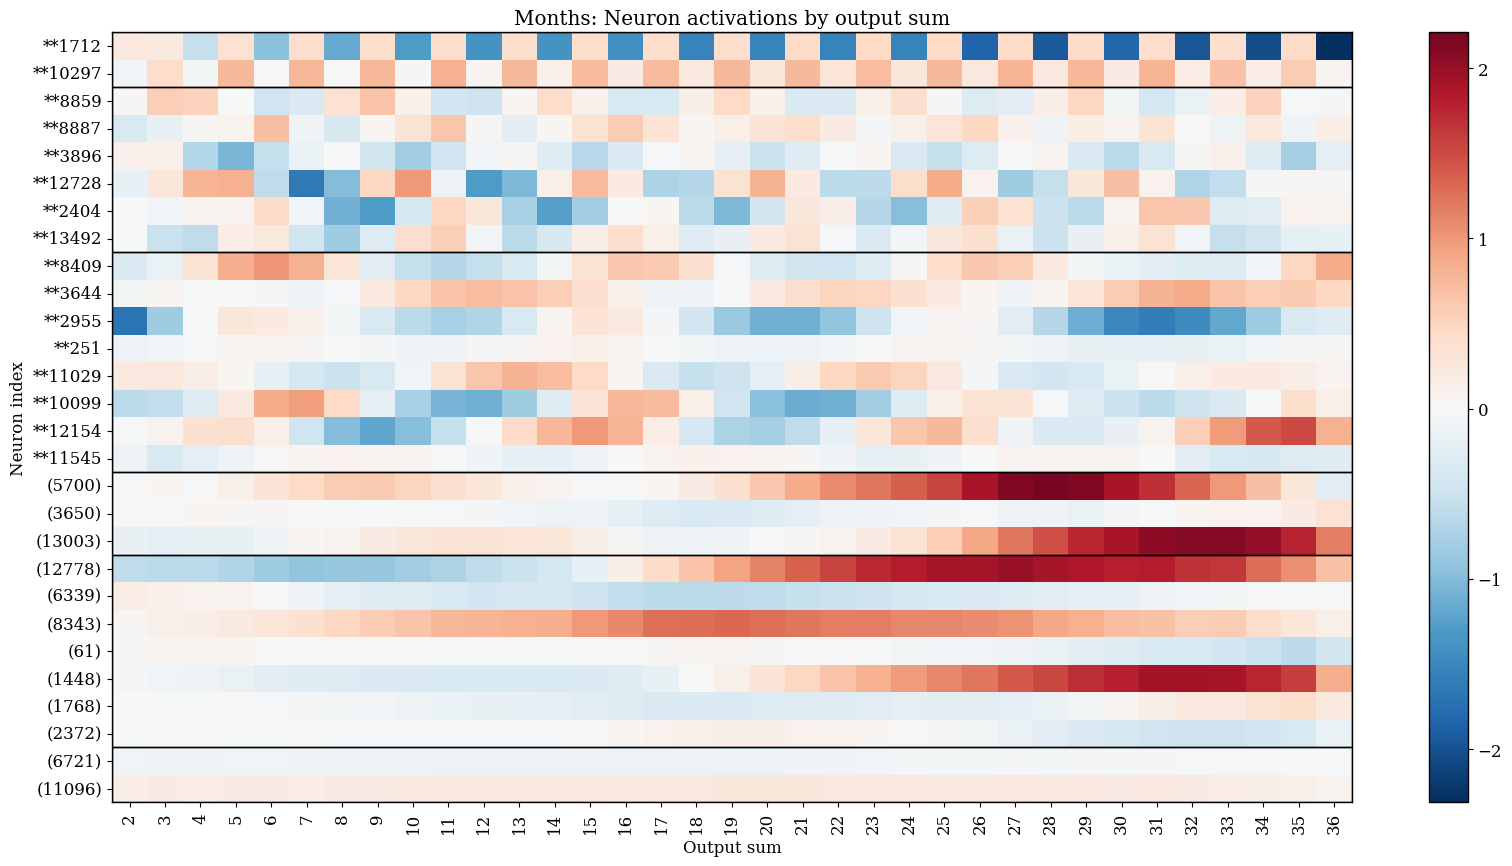

In [5]:
import itertools 
import seaborn as sns 
from itertools import groupby
from tasks import TASKS

task = "months"
num_to_idx = TASKS[task]["num_to_idx"]

all_prompts = []

causal_model = TASKS[task]["causal_model"]
input_vars = causal_model.inputs
input_value_lists = [causal_model.values[v] for v in input_vars]

for combo in itertools.product(*input_value_lists):
    inp = dict(zip(input_vars, combo))
    result = causal_model.run_forward(inp)
    all_prompts.append({
        **result, **inp,
    })

try:
    premods = [d["premod"] for d in all_prompts]
except KeyError:
    assert task == "addition"
    premods = [int(d["output"]) for d in all_prompts]
    
prompts = [d["raw_input"] for d in all_prompts]

with torch.no_grad():
    with model.trace(prompts):
        neuron_activations = model.model.layers[18].mlp.down_proj.input[:, -1].save()

# neuron_activations [288, 14336]
# plot all the neuron's activations as a wave over possible output sums. 
premod_avgs = {pm : torch.zeros(neuron_activations.shape[-1]).cuda() for pm in premods}
premod_cts = {pm : 0 for pm in premods}
for premod_label, nas in zip(premods, neuron_activations):
    premod_avgs[premod_label] += nas 
    premod_cts[premod_label] += 1
premod_avgs = {k: v / premod_cts[k] for k, v in premod_avgs.items()}


if task == "months":
    x = list(range(2, 37))
elif task == "addition":
    x = list(range(2,201))
elif task == "weekdays":
    x = list(range(2, 22))
elif task == "hours":
    x = list(range(1, 72))

heatmap_data = []
large_mods = []
for neuron_idx in addition_neurons:
    row = []
    for output_sum in x: 
        row.append(premod_avgs[output_sum][neuron_idx].item())
    heatmap_data.append(row)
    
    if neuron_idx in [6721, 11096]:
        large_mods.append(row)

import numpy as np
heatmap_data = np.array(heatmap_data)

xlabels = [t for t in x]
ylabels = []                                                                                                                                                                                                                   
for n in addition_neurons:                                                                                                                                                                                                                        
    if n in neurons_per_task[task]:
        ylabels.append(f"**{n}")  # mathtext bold
    else:                                                                                                                                                                                                                                         
        ylabels.append(f"({n})")

fig, ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    heatmap_data,
    xticklabels=xlabels,
    yticklabels=ylabels,
    cmap='RdBu_r',
    center=0,
    ax=ax,
    rasterized=True
)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xticks([num+0.5 for num in range(len(x))])
ax.set_xticklabels(xlabels, rotation=90)
ax.set_xlabel("Output sum")
ax.set_ylabel("Neuron index")
ax.set_title(f"{task.title()}: Neuron activations by output sum")

# Draw boxes around clusters on the heatmap                                                                                                                                                                                                       
for _, group in groupby(enumerate(cluster_labels), key=lambda x: x[1]):
    indices = [i for i, _ in group]                                                                                                                                                                                                               
    y_start = indices[0]                                                                                                                                                                                                                          
    y_end = indices[-1] + 1
    ax.add_patch(plt.Rectangle(                                                                                                                                                                                                               
        (0, y_start), len(x), y_end - y_start,                                                                                                                                                                                                    
        fill=False, edgecolor='black', linewidth=1                                                                                                                                                                                             
    ))  

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

ax.collections[0].colorbar.outline.set_visible(True)                                                                                                                                                              
ax.collections[0].colorbar.outline.set_linewidth(1)
plt.show()